In [6]:
import json
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [9]:
experiments = {
    'vit_finetune': 'outputs/vit_finetune/logs/summary.json',
}

results = []
for name, path in experiments.items():
    with open(path, 'r') as f:
        data = json.load(f)
    results.append({
        'experiment': name,
        'best_epoch': data['best_epoch'],
        'val_f1': data['best_val_macro_f1'],
        'params': data['trainable_parameters']
    })

df = pd.DataFrame(results)
print(df)

     experiment  best_epoch    val_f1   params
0  vit_finetune           8  0.936514  5525188


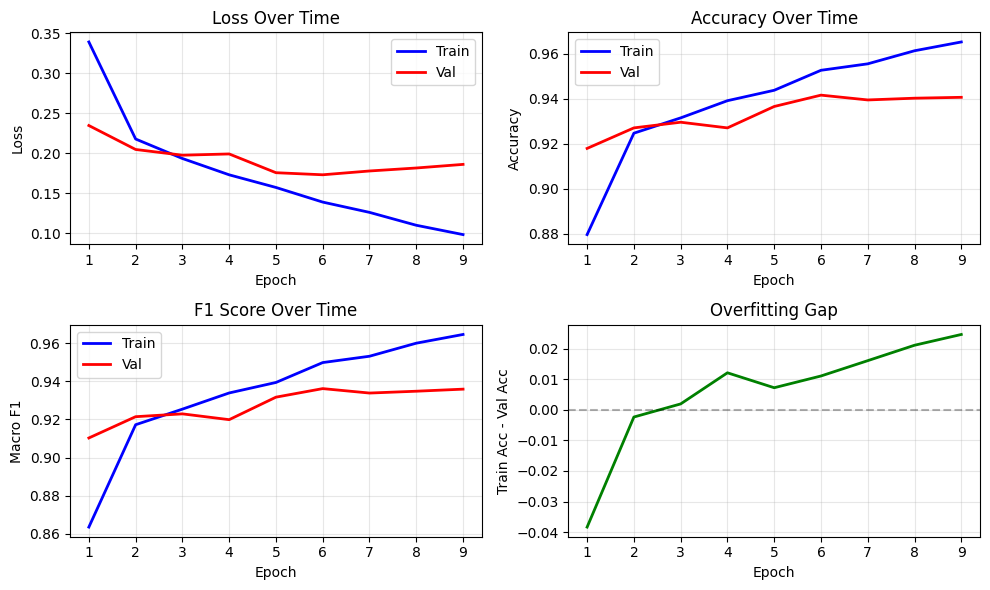

In [11]:
with open('outputs/vit_finetune/logs/history.json', 'r') as f:
    history = json.load(f)

train_data = history['train']
val_data = history['val']

epochs = [e['epoch'] for e in train_data]
train_loss = [e['loss'] for e in train_data]
val_loss = [e['loss'] for e in val_data]
train_acc = [e['accuracy'] for e in train_data]
val_acc = [e['accuracy'] for e in val_data]
train_f1 = [e['macro_f1'] for e in train_data]
val_f1 = [e['macro_f1'] for e in val_data]


fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Loss
axes[0, 0].plot(epochs, train_loss, 'b-', label='Train', linewidth=2)
axes[0, 0].plot(epochs, val_loss, 'r-', label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, train_acc, 'b-', label='Train', linewidth=2)
axes[0, 1].plot(epochs, val_acc, 'r-', label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Over Time')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[1, 0].plot(epochs, train_f1, 'b-', label='Train', linewidth=2)
axes[1, 0].plot(epochs, val_f1, 'r-', label='Val', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1')
axes[1, 0].set_title('F1 Score Over Time')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Train - Val
gap = [t - v for t, v in zip(train_acc, val_acc)]
axes[1, 1].plot(epochs, gap, 'g-', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Train Acc - Val Acc')
axes[1, 1].set_title('Overfitting Check')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/vit_finetune/figures/training_analysis.png', dpi=300, bbox_inches='tight')
plt.show()